In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# load Data

In [ ]:

# Configuration
sns.set(style="whitegrid")
DATA_PATH = Path("data")

# Fonction de chargement
def load_imdb_data(split="train"):
    texts = []
    labels = []
    for label_type in ["pos", "neg"]:
        dir_path = DATA_PATH / split / label_type
        for fname in os.listdir(dir_path):
            with open(dir_path / fname, encoding="utf-8") as f:
                texts.append(f.read())
                labels.append(1 if label_type == "pos" else 0)
    return pd.DataFrame({"review": texts, "label": labels})

# Chargement des jeux de données
train_df = load_imdb_data("train")
test_df = load_imdb_data("test")




In [3]:
# Aperçu
print(f"Train size: {len(train_df)} | Test size: {len(test_df)}")
display(train_df.sample(3))

Train size: 25000 | Test size: 25000


,review,label
17529,It's very sad that Lucian Pintilie does not st...,0
22280,The power rangers is definitely the worst tele...,0
400,<br /><br />There is STAR TREK canon -- lots o...,1


In [4]:
# Ajout de la longueur de chaque review
train_df["review_length"] = train_df["review"].apply(lambda x: len(x.split()))
test_df["review_length"] = test_df["review"].apply(lambda x: len(x.split()))

# Analyse des données

/tmp/ipykernel_2784468/3040776543.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Négatif", "Positif"])
/tmp/ipykernel_2784468/3040776543.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Négatif", "Positif"])


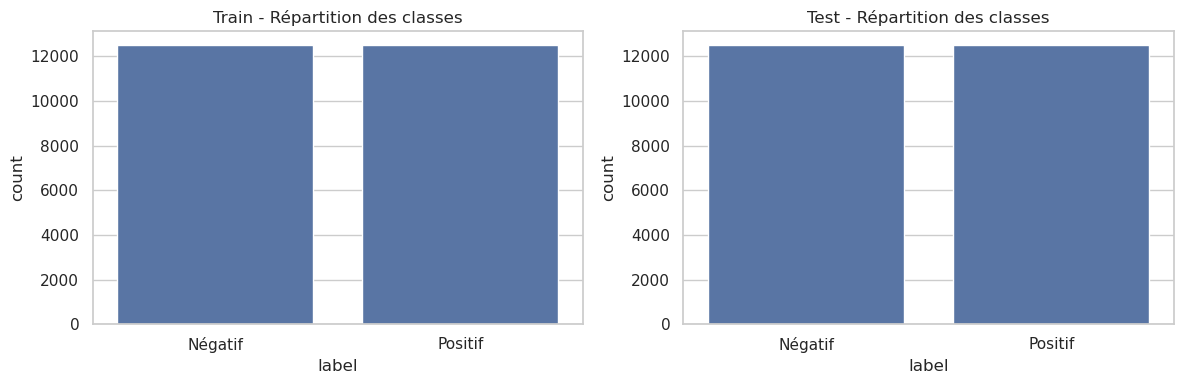

In [5]:
# Répartition des classes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=train_df, x="label", ax=axes[0])
axes[0].set_title("Train - Répartition des classes")
axes[0].set_xticklabels(["Négatif", "Positif"])

sns.countplot(data=test_df, x="label", ax=axes[1])
axes[1].set_title("Test - Répartition des classes")
axes[1].set_xticklabels(["Négatif", "Positif"])
plt.tight_layout()
plt.show()


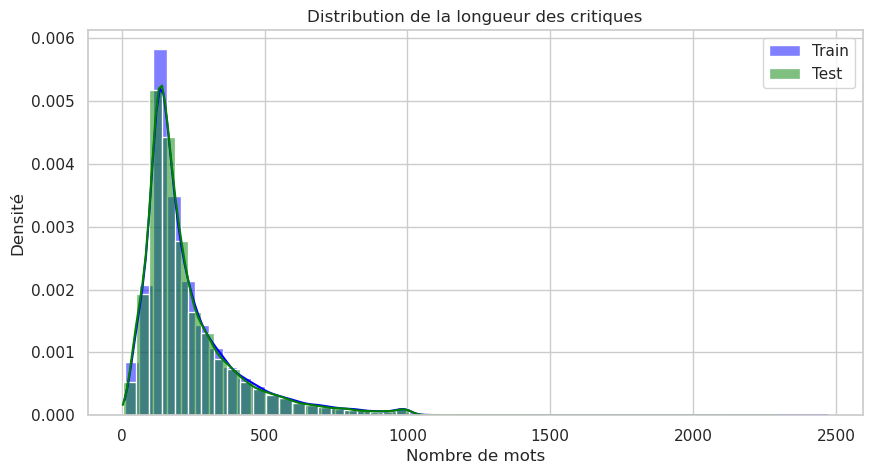

In [6]:
# Distribution des longueurs
plt.figure(figsize=(10, 5))
sns.histplot(train_df["review_length"], color="blue", bins=50, kde=True, label="Train", stat="density")
sns.histplot(test_df["review_length"], color="green", bins=50, kde=True, label="Test", stat="density")
plt.legend()
plt.title("Distribution de la longueur des critiques")
plt.xlabel("Nombre de mots")
plt.ylabel("Densité")
plt.show()

les deux datasets  sont équilibrés, avec une longueur de critique qui suit une distribution similaire.


# Nuage de mots 

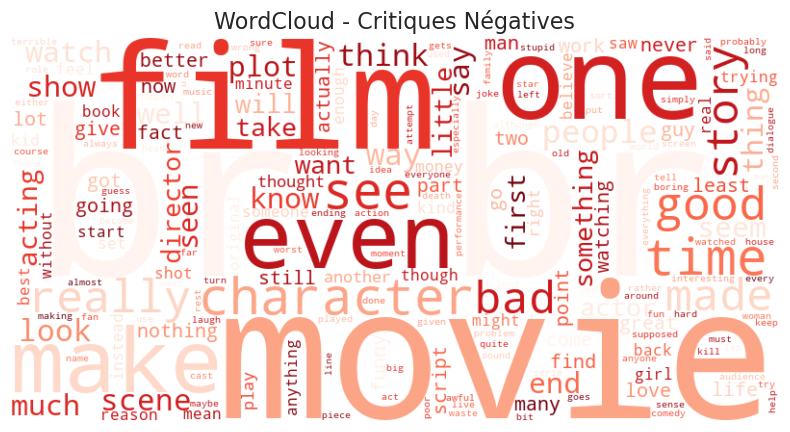

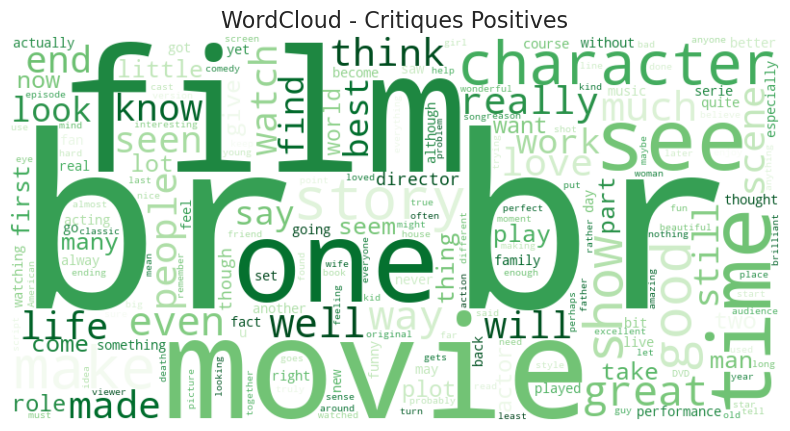

In [ ]:
from wordcloud import WordCloud, STOPWORDS


# Fusionner tous les textes d'une classe
def generate_wordcloud(df, label_value, title, color="black"):
    text = " ".join(df[df["label"] == label_value]["review"].tolist())
    stopwords = set(STOPWORDS)
    wordcloud = WordCloud(width=800, height=400, background_color="white",
                          stopwords=stopwords, colormap=color).generate(text)

    # Affichage
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

# Nuage de mots pour les critiques négatives
generate_wordcloud(train_df, label_value=0, title="WordCloud - Critiques Négatives", color="Reds")

# Nuage de mots pour les critiques positives
generate_wordcloud(train_df, label_value=1, title="WordCloud - Critiques Positives", color="Greens")


In [8]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /users/eleves-a/2024/zakarya.elmimouni/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

# Analyse des Bi-grams

[nltk_data] Downloading package stopwords to
[nltk_data]     /users/eleves-a/2024/zakarya.elmimouni/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


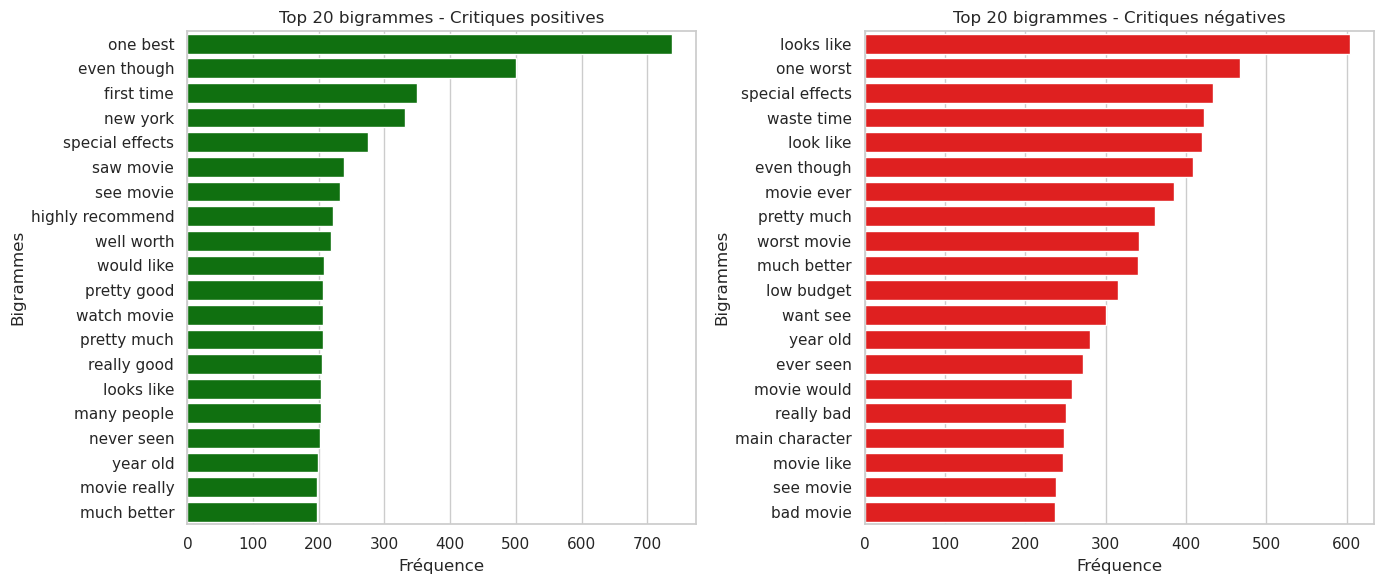

In [ ]:
from nltk.corpus import stopwords
from nltk import word_tokenize, ngrams
from collections import Counter

nltk.download('stopwords')

stop_words = set(stopwords.words("english"))

# Prétraitement basique
def preprocess(text):
    tokens = text.lower().split()
    return [t for t in tokens if t.isalpha() and t not in stop_words]

# Fonction pour extraire les bigrammes les plus fréquents
def get_top_bigrams(df, label, n=20):
    texts = df[df['label'] == label]['review'].tolist()
    bigrams = []
    for text in texts:
        tokens = preprocess(text)
        bigrams.extend(list(ngrams(tokens, 2)))
    top = Counter(bigrams).most_common(n)
    return [' '.join(b) for b, _ in top], [count for _, count in top]

# Appliquer pour positives (label = 1) et négatives (label = 0)
top_pos, freq_pos = get_top_bigrams(train_df, label=1)
top_neg, freq_neg = get_top_bigrams(train_df, label=0)

# Figure double
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=freq_pos, y=top_pos, color='green')
plt.title("Top 20 bigrammes - Critiques positives")
plt.xlabel("Fréquence")
plt.ylabel("Bigrammes")

plt.subplot(1, 2, 2)
sns.barplot(x=freq_neg, y=top_neg, color='red')
plt.title("Top 20 bigrammes - Critiques négatives")
plt.xlabel("Fréquence")
plt.ylabel("Bigrammes")

plt.tight_layout()
plt.savefig("figures/bigrams_by_sentiment.png", dpi=300)
plt.show()

# 1- Approche simple TF_IDF + Classifieur

In [ ]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import make_pipeline



# 1. Vectorisation TF-IDF
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

# 2. Séparation des données
X = train_df['review']
y = train_df['label']

# 3. Division des données en ensembles d'entraînement et de validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Création du modèle avec un pipeline
# Utilisation de Naive Bayes avec la vectorisation TF-IDF
model = make_pipeline(TfidfVectorizer(stop_words='english', max_features=5000), MultinomialNB())

# 5. Entraînement du modèle
model.fit(X_train, y_train)

# 6. Prédiction sur l'ensemble de validation
y_pred = model.predict(X_val)

# 7. Évaluation du modèle
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print("Classification Report:\n", classification_report(y_val, y_pred))

# 8. Prédiction sur le test
y_test_pred = model.predict(test_df['review'])
print(f"Test Accuracy: {accuracy_score(test_df['label'], y_test_pred):.4f}")


Accuracy: 0.8476
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      2485
           1       0.85      0.85      0.85      2515

    accuracy                           0.85      5000
   macro avg       0.85      0.85      0.85      5000
weighted avg       0.85      0.85      0.85      5000

Test Accuracy: 0.8394


# 2- Approche simplifié du papier: Semantic + Sentiment (inspiré du papier)

préparation des données 

In [11]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

# Limiter le vocabulaire à 5000 mots, pas de stopwords
vectorizer = CountVectorizer(max_features=5000, stop_words='english', binary=True)
X_train_vec = vectorizer.fit_transform(train_df["review"]).toarray()
y_train = train_df["label"].values

X_test_vec = vectorizer.transform(test_df["review"]).toarray()
y_test = test_df["label"].values

# Dictionnaire token -> index
vocab = vectorizer.vocabulary_
inv_vocab = {i: w for w, i in vocab.items()}


 Implémentation du modèle 

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SentimentWordVectorModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.bias = nn.Parameter(torch.zeros(vocab_size))  # b_w
        self.classifier = nn.Linear(embed_dim, 1)  # ψ

    def forward(self, bow_input):
        # bow_input : batch_size × vocab_size
        θ = bow_input @ self.embed.weight / bow_input.sum(1, keepdim=True)  # équivalent à moyenne pondérée
        logits = self.classifier(θ).squeeze(1)
        return logits

    def get_word_vectors(self):
        return self.embed.weight.data.cpu().numpy()


 Entraînement (supervisé avec logistic loss)

In [13]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score

# Tensors
X_train_tensor = torch.tensor(X_train_vec, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_vec, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)

# Model
model = SentimentWordVectorModel(vocab_size=5000, embed_dim=50)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

# Entraînement
for epoch in range(10):
    model.train()
    for X_batch, y_batch in train_loader:
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if epoch % 2 == 0:
        model.eval()
        with torch.no_grad():
            logits = model(X_test_tensor)
            preds = torch.sigmoid(logits).round()
            acc_test = accuracy_score(y_test_tensor.numpy(), preds.numpy())
            acc_train = accuracy_score(y_train_tensor.numpy(), torch.sigmoid(model(X_train_tensor)).round().numpy())
            print(f"Epoch {epoch+1} - Train Accuracy: {acc_train:.4f} - Test Accuracy: {acc_test:.4f}")



        
    


Epoch 1 - Train Accuracy: 0.8169 - Test Accuracy: 0.8032
Epoch 3 - Train Accuracy: 0.8833 - Test Accuracy: 0.8638
Epoch 5 - Train Accuracy: 0.9048 - Test Accuracy: 0.8739
Epoch 7 - Train Accuracy: 0.9158 - Test Accuracy: 0.8760
Epoch 9 - Train Accuracy: 0.9225 - Test Accuracy: 0.8745


Evaluation

In [14]:
model.eval()
with torch.no_grad():
    preds = torch.sigmoid(model(X_test_tensor)).cpu().numpy()
    preds_class = (preds > 0.5).astype(int)
    acc = accuracy_score(y_test, preds_class)
    print(f"Test Accuracy: {acc:.4f}")


Test Accuracy: 0.8730


# 3-Implémentation de l'approche du papier 

Apprentissage des vecteurs de mots en maximisant la log vraisemblance 

In [ ]:

class SemanticLikelihoodModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.word_embeddings = nn.Parameter(torch.randn(vocab_size, embed_dim) * 0.01)  # φ_w
        self.bias = nn.Parameter(torch.zeros(vocab_size))                                # b_w

    def forward(self, bow_input):
        """
        bow_input: [batch_size, vocab_size] (binary vector of word presence)
        """
        batch_size = bow_input.size(0)
        device = bow_input.device

        # Initialise un vecteur θ par document, avec requires_grad pour l'optimiser
        theta = torch.randn(batch_size, self.word_embeddings.shape[1], requires_grad=True, device=device)

        # Softmax (logits = θ @ φ^T + b)
        logits = torch.matmul(theta, self.word_embeddings.T) + self.bias  # [batch, vocab]
        log_probs = F.log_softmax(logits, dim=1)

        # Calcul de la log-vraisemblance sur les mots présents dans le doc
        log_likelihood = torch.sum(bow_input * log_probs, dim=1).mean()

        return -log_likelihood  # on retourne la loss (négative log-vraisemblance)


Epoch 1 - Train NLL: 591.2160 | Test NLL: 564.9302
Epoch 2 - Train NLL: 570.0973 | Test NLL: 549.7486
Epoch 3 - Train NLL: 558.8339 | Test NLL: 542.1093
Epoch 4 - Train NLL: 553.6456 | Test NLL: 538.8330
Epoch 5 - Train NLL: 551.5484 | Test NLL: 537.6788
Epoch 6 - Train NLL: 551.2313 | Test NLL: 537.4126
Epoch 7 - Train NLL: 550.8431 | Test NLL: 537.3392
Epoch 8 - Train NLL: 551.0316 | Test NLL: 537.3070
Epoch 9 - Train NLL: 550.7925 | Test NLL: 537.2882
Epoch 10 - Train NLL: 550.7498 | Test NLL: 537.2859
Epoch 11 - Train NLL: 550.8271 | Test NLL: 537.2663
Epoch 12 - Train NLL: 550.8183 | Test NLL: 537.2724


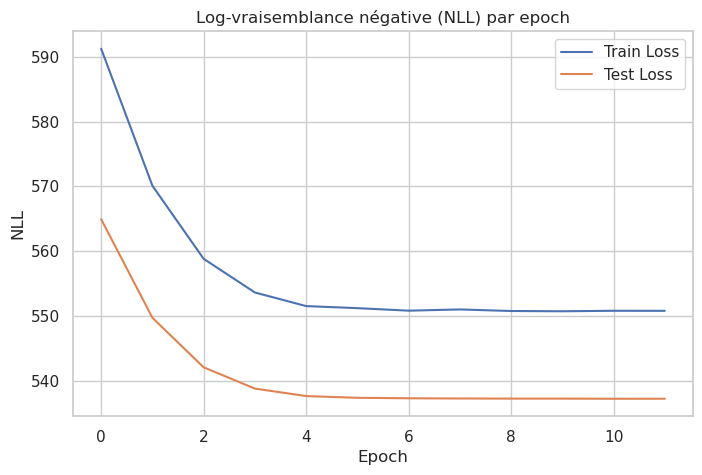

In [ ]:
batch_size = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor), batch_size=batch_size)

model = SemanticLikelihoodModel(vocab_size=X_train_tensor.shape[1], embed_dim=50).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses = []
test_losses = []

for epoch in range(12):
    model.train()
    train_loss = 0
    for X_batch, in train_loader:
        X_batch = X_batch.to(device)
        loss = model(X_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    with torch.no_grad():
        test_loss = 0
        for X_batch, in test_loader:
            X_batch = X_batch.to(device)
            loss = model(X_batch)
            test_loss += loss.item()
        avg_test_loss = test_loss / len(test_loader)
        test_losses.append(avg_test_loss)

    print(f"Epoch {epoch+1} - Train NLL: {avg_train_loss:.4f} | Test NLL: {avg_test_loss:.4f}")

# Tracer les deux courbes
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("Log-vraisemblance négative (NLL) par epoch")
plt.xlabel("Epoch")
plt.ylabel("NLL")
plt.legend()
plt.grid(True)
plt.show()

Entrainement d'une régression logistic sur les vecteurs de documents appris 

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
# Étape 1 – Représentation des documents par moyenne pondérée des φw
def compute_document_vectors(bow_matrix, word_vectors):
    doc_vecs = bow_matrix @ word_vectors
    lengths = bow_matrix.sum(axis=1, keepdims=True) + 1e-10
    return doc_vecs / lengths

# Conversion tensor → numpy
X_train_bow = X_train_tensor.numpy()
X_test_bow = X_test_tensor.numpy()

# Moyenne des vecteurs de mots φw
phi_w = model.word_embeddings.detach().cpu().numpy()
X_train_repr = compute_document_vectors(X_train_bow, phi_w)
X_test_repr = compute_document_vectors(X_test_bow, phi_w)

# Étape 2 – Recherche d'hyperparamètre pour C (régularisation)
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
clf = LogisticRegression(max_iter=1000)
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_repr, y_train)

# Meilleur modèle
best_model = grid_search.best_estimator_
print("Meilleur paramètre C :", grid_search.best_params_['C'])

# Étape 3 – Évaluation finale
train_preds = best_model.predict(X_train_repr)
test_preds = best_model.predict(X_test_repr)

train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")


Meilleur paramètre C : 100
Train Accuracy: 0.6893
Test Accuracy:  0.6976


On essaie un modèle Random Forest au lieu de la régression logistique

In [18]:
# on essaie aussi un Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'n_estimators': [5, 10,80],
    'max_depth': [5, 10, 20],
    
}

rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_repr, y_train)

rf_best = rf_grid.best_estimator_
print("Random Forest - Best Params:", rf_grid.best_params_)
print("Train Accuracy:", accuracy_score(y_train, rf_best.predict(X_train_repr)))
print("Test Accuracy :", accuracy_score(y_test, rf_best.predict(X_test_repr)))


Random Forest - Best Params: {'max_depth': 10, 'n_estimators': 80}
Train Accuracy: 0.87072
Test Accuracy : 0.6762


on essaie aussi un modèle Xgboost

In [19]:
from xgboost import XGBClassifier

xgb_param_grid = {
    'n_estimators': [10, 100],
    'max_depth': [3, 6],
    'learning_rate': [0.05, 0.1],
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0)
xgb_grid = GridSearchCV(xgb, xgb_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train_repr, y_train)

xgb_best = xgb_grid.best_estimator_
print("XGBoost - Best Params:", xgb_grid.best_params_)
print("Train Accuracy:", accuracy_score(y_train, xgb_best.predict(X_train_repr)))
print("Test Accuracy :", accuracy_score(y_test, xgb_best.predict(X_test_repr)))


XGBoost - Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Train Accuracy: 0.71496
Test Accuracy : 0.68512


Conclusion: les Trois modèles (Régression logistique, Random Forest, Xgboost) donnent des résultats similaires qui sont pas très bien 

# 4-Modèle Bert

In [ ]:
from datasets import Dataset
# Préparation des données 
# train_df et test_df doivent contenir deux colonnes : 'text' et 'label'
train_df = train_df.rename(columns={"review": "text"})
test_df = test_df.rename(columns={"review": "text"})

#Convertir en Dataset HuggingFace

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)


In [ ]:
from transformers import pipeline
from tqdm import tqdm

# 1. Charger le modèle de classification
classifier = pipeline("text-classification", model="distilbert-base-uncased-finetuned-sst-2-english", truncation=True)

# 2. Appliquer la prédiction sur un ensemble (train ou test)
def predict_sentiment(texts):
    preds = []
    for result in tqdm(classifier(texts, batch_size=8), desc="Inference"):
        label = 1 if result['label'] == 'POSITIVE' else 0
        preds.append(label)
    return preds

# 3. Appliquer sur ton test set
test_texts = test_df['text'].tolist()
true_labels = test_df['label'].tolist()

pred_labels = predict_sentiment(test_texts)

# 4. Évaluer
acc = accuracy_score(true_labels, pred_labels)
print(f" Zero-shot Test Accuracy: {acc:.4f}")


Device set to use cuda:0
Inference: 100%|██████████| 25000/25000 [00:00<00:00, 5263407.29it/s]

✅ Zero-shot Test Accuracy: 0.8907
